# Topic Modeling - Experiments

Compare 3 text encoding methods (Bag of Words, TF-IDF, Embeddings) across 4 classifiers (KMeans, KNN, Decision Tree, Naive Bayes) on arXiv abstract classification.

In [44]:
import sys
import os
os.makedirs('./outputs/figures', exist_ok=True)
sys.path.append('..')
from src.dataset import load_raw_dataset, filter_sample, build_label_mappings, split_dataset
from src.preprocessing import preprocess_samples
from src.encoders import build_feature_matrices
from src.models import train_and_test_kmeans, train_and_test_knn, train_and_test_decision_tree, train_and_test_naive_bayes
from src.visualization import plot_confusion_matrix

## 1. Data Preparation

Load dataset từ HuggingFace, filter 1000 samples single-label thuộc 5 category, preprocess text và split train/test.

In [42]:
CACHE_DIR = '../cache'
CATEGORIES = ['astro-ph', 'cond-mat', 'cs', 'math', 'physics']
MAX_SAMPLES = 1000

ds = load_raw_dataset(CACHE_DIR)
samples = filter_sample(ds, CATEGORIES, MAX_SAMPLES)
preprocessed_samples = preprocess_samples(samples)
sorted_labels, label_to_id, id_to_label = build_label_mappings(preprocessed_samples)
X_train, X_test, y_train, y_test = split_dataset(preprocessed_samples, label_to_id)

## 2. Text Encoding

Encode text bằng 3 phương pháp: Bag of Words, TF-IDF, và Sentence Embeddings (`multilingual-e5-base`).

In [10]:
features = build_feature_matrices(X_train, X_test)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6332.68it/s]


## 3. Model Training & Evaluation

Train và evaluate từng model trên 3 loại encoder. Kết quả được in ra accuracy và confusion matrix.

### 3.1 KMeans

KMeans là thuật toán clustering không có giám sát. Sau khi cluster, gán nhãn cho mỗi cluster bằng label phổ biến nhất trong cluster đó.

/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


KMeans (bow): 0.5600


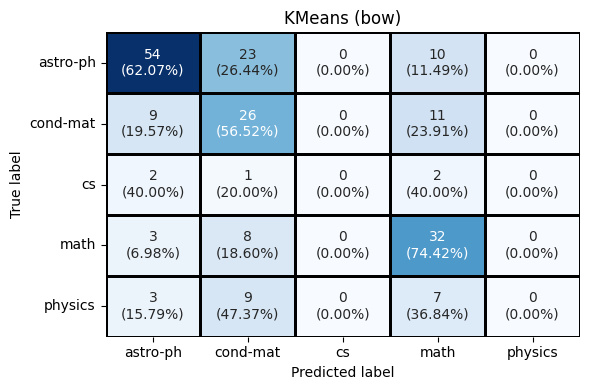

In [61]:

X_train_enc, X_test_enc = features['bow']
        
# KMeans
y_pred, accuracy, report = train_and_test_kmeans(X_train_enc, X_test_enc, y_train, y_test, 
                                                    n_clusters=len(label_to_id), id_to_label=id_to_label)
print(f"KMeans (bow): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"KMeans (bow)", 
                        save_path=f'./outputs/figures/kmeans_bow.png')

/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


KMeans (tfidf): 0.6150


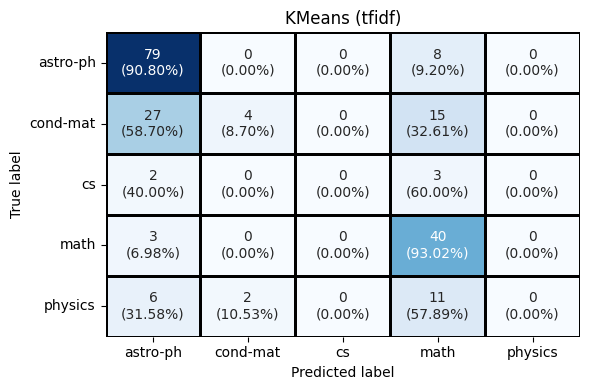

In [60]:
X_train_enc, X_test_enc = features['tfidf']
        
# KMeans
y_pred, accuracy, report = train_and_test_kmeans(X_train_enc, X_test_enc, y_train, y_test, 
                                                    n_clusters=len(label_to_id), id_to_label=id_to_label)
print(f"KMeans (tfidf): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"KMeans (tfidf)", 
                        save_path=f'./outputs/figures/kmeans_tfidf.png')

/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


KMeans (embedding): 0.8400


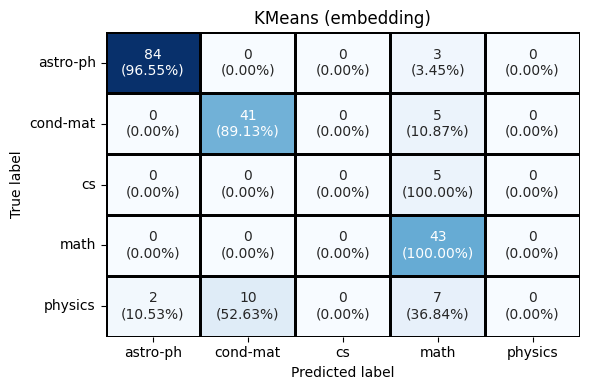

In [59]:
X_train_enc, X_test_enc = features['embedding']
        
# KMeans
y_pred, accuracy, report = train_and_test_kmeans(X_train_enc, X_test_enc, y_train, y_test, 
                                                    n_clusters=len(label_to_id), id_to_label=id_to_label)
print(f"KMeans (embedding): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"KMeans (embedding)", 
                        save_path=f'./outputs/figures/kmeans_embedding.png')

**Nhận xét KMeans:**

| Encoder | Accuracy |
|---------|----------|
| Bag of Words | 0.56 |
| TF-IDF | 0.615 |
| Embeddings | 0.84 |

- KMeans với BoW và TF-IDF cho kết quả thấp vì đây là phương pháp clustering không giám sát — nó không học từ nhãn mà chỉ tìm cụm tự nhiên trong dữ liệu, trong khi BoW/TF-IDF tạo ra vector rất thưa (sparse) và nhiều chiều.
- Embeddings cải thiện đáng kể (0.84) vì vector embedding nắm bắt được ngữ nghĩa, giúp các abstract cùng chủ đề tập trung thành cụm rõ ràng hơn.

### 3.2 KNN (K-Nearest Neighbors)

KNN phân loại dựa trên k điểm dữ liệu gần nhất trong không gian feature. Sử dụng `k=5`.

KNN (bow): 0.5300


/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


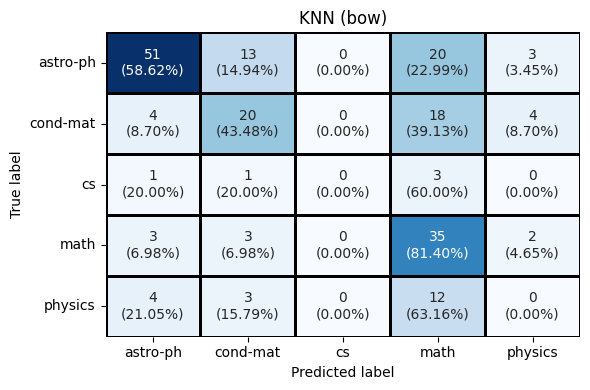

In [62]:
X_train_enc, X_test_enc = features['bow']
        
# KNN
y_pred, accuracy, report = train_and_test_knn(X_train_enc, X_test_enc, y_train, y_test, 
                                              sorted_labels, n_neighbors=5)
print(f"KNN (bow): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"KNN (bow)", 
                        save_path=f'./outputs/figures/knn_bow.png')

/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


KNN (tfidf): 0.8150


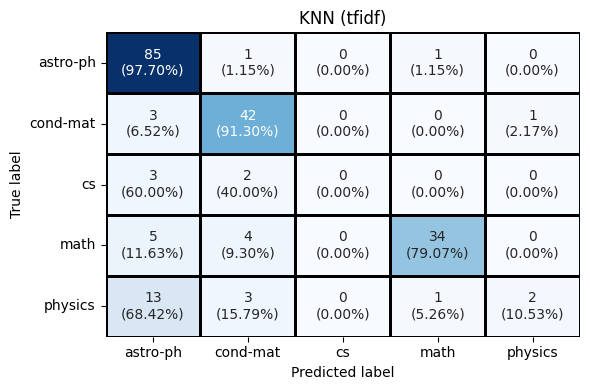

In [63]:
X_train_enc, X_test_enc = features['tfidf']
        
# KNN
y_pred, accuracy, report = train_and_test_knn(X_train_enc, X_test_enc, y_train, y_test,
                                              sorted_labels, n_neighbors=5)
print(f"KNN (tfidf): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"KNN (tfidf)", 
                        save_path=f'./outputs/figures/knn_tfidf.png')

KNN (embedding): 0.8900


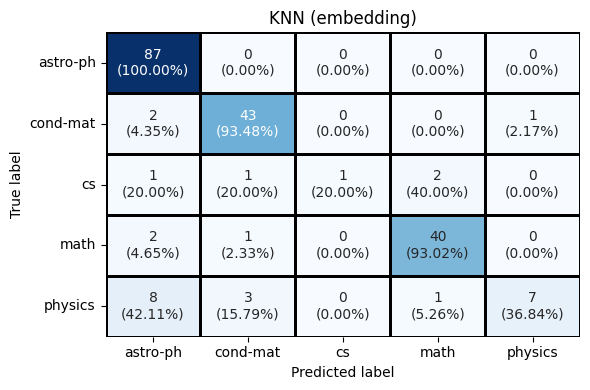

In [64]:
X_train_enc, X_test_enc = features['embedding']
        
# KNN
y_pred, accuracy, report = train_and_test_knn(X_train_enc, X_test_enc, y_train, y_test, 
                                              sorted_labels, n_neighbors=5)
print(f"KNN (embedding): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"KNN (embedding)", 
                        save_path=f'./outputs/figures/knn_embedding.png')

**Nhận xét KNN:**

| Encoder | Accuracy |
|---------|----------|
| Bag of Words | 0.53 |
| TF-IDF | 0.815 |
| Embeddings | 0.89 |

- BoW cho kết quả thấp nhất vì KNN dựa vào khoảng cách — vector BoW không chuẩn hóa nên khoảng cách bị ảnh hưởng bởi độ dài văn bản.
- TF-IDF cải thiện rõ rệt (0.815) vì đã giảm trọng số các từ phổ biến, khoảng cách giữa các vector phản ánh tốt hơn sự tương đồng về chủ đề.
- Embeddings đạt cao nhất (0.89) vì vector ngữ nghĩa giúp các abstract cùng chủ đề gần nhau hơn trong không gian vector.

### 3.3 Decision Tree

Decision Tree phân loại bằng cách học các luật quyết định từ dữ liệu training.

Decision Tree (bow): 0.6350


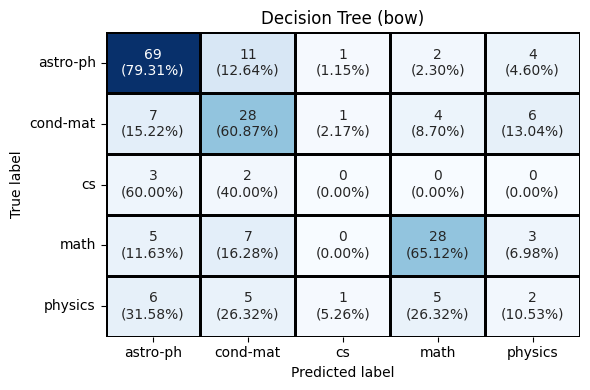

In [65]:
X_train_enc, X_test_enc = features['bow']
        
# Decision Tree
y_pred, accuracy, report = train_and_test_decision_tree(X_train_enc, X_test_enc, y_train, y_test, 
                                              sorted_labels)
print(f"Decision Tree (bow): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"Decision Tree (bow)", 
                        save_path=f'./outputs/figures/decision_tree_bow.png')

Decision Tree (tfidf): 0.5950


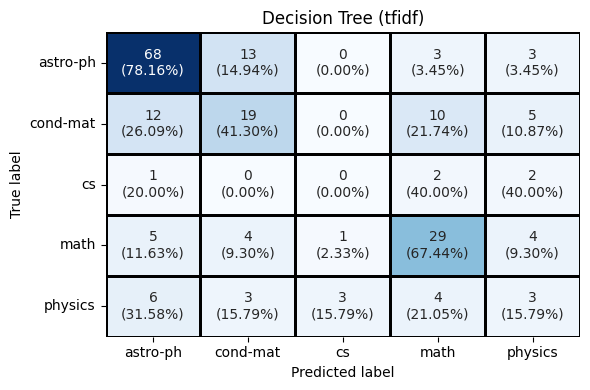

In [66]:
X_train_enc, X_test_enc = features['tfidf']
        
# Decision Tree
y_pred, accuracy, report = train_and_test_decision_tree(X_train_enc, X_test_enc, y_train, y_test, 
                                              sorted_labels)
print(f"Decision Tree (tfidf): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"Decision Tree (tfidf)", 
                        save_path=f'./outputs/figures/decision_tree_tfidf.png')

Decision Tree (embedding): 0.7150


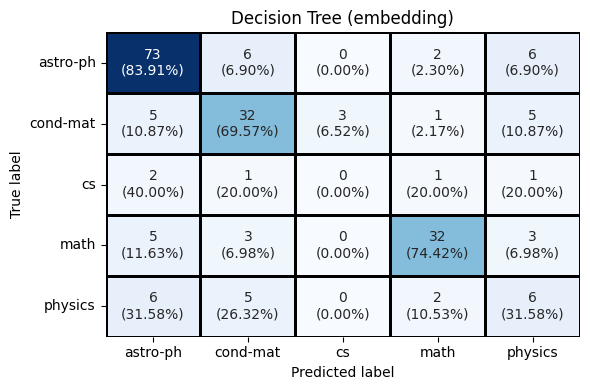

In [67]:
X_train_enc, X_test_enc = features['embedding']
        
# Decision Tree
y_pred, accuracy, report = train_and_test_decision_tree(X_train_enc, X_test_enc, y_train, y_test, 
                                              sorted_labels)
print(f"Decision Tree (embedding): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"Decision Tree (embedding)", 
                        save_path=f'./outputs/figures/decision_tree_embedding.png')

**Nhận xét Decision Tree:**

| Encoder | Accuracy |
|---------|----------|
| Bag of Words | 0.635 |
| TF-IDF | 0.595 |
| Embeddings | 0.715 |

- Decision Tree nhìn chung cho kết quả thấp hơn các model khác vì dễ bị overfitting với dữ liệu văn bản có số chiều cao.
- BoW cho kết quả nhỉnh hơn TF-IDF một chút — Decision Tree hoạt động tốt hơn với giá trị nguyên (count) hơn là giá trị thực (TF-IDF weight).
- Embeddings cải thiện lên 0.715 nhưng vẫn thấp hơn KNN và Naive Bayes cùng encoder.

### 3.4 Naive Bayes

Naive Bayes là classifier xác suất dựa trên định lý Bayes, giả định các feature độc lập với nhau.

/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


Naive Bayes (bow): 0.8500


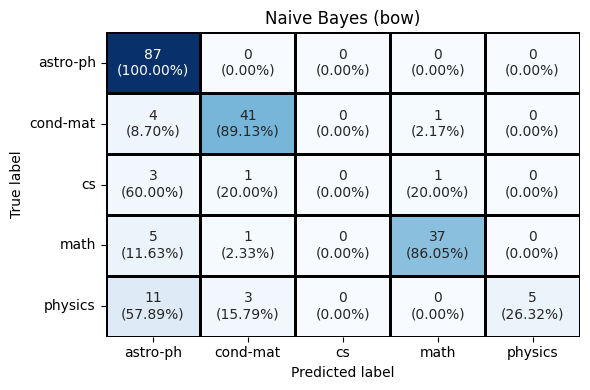

In [68]:
X_train_enc, X_test_enc = features['bow']
        
# Naive bayes
y_pred, accuracy, report = train_and_test_naive_bayes(X_train_enc, X_test_enc, y_train, y_test, 
                                              sorted_labels)
print(f"Naive Bayes (bow): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"Naive Bayes (bow)", 
                        save_path=f'./outputs/figures/naive_bayes_bow.png')

Naive Bayes (tfidf): 0.8300


/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


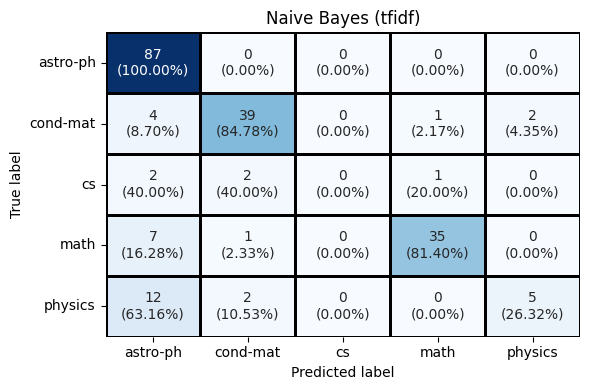

In [69]:
X_train_enc, X_test_enc = features['tfidf']
        
# Naive bayes
y_pred, accuracy, report = train_and_test_naive_bayes(X_train_enc, X_test_enc, y_train, y_test, 
                                              sorted_labels)
print(f"Naive Bayes (tfidf): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"Naive Bayes (tfidf)", 
                        save_path=f'./outputs/figures/naive_bayes_tfidf.png')

Naive Bayes (embedding): 0.8900


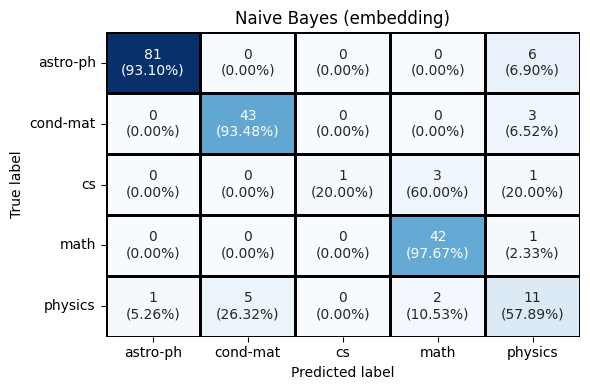

In [70]:
X_train_enc, X_test_enc = features['embedding']
        
# Naive bayes
y_pred, accuracy, report = train_and_test_naive_bayes(X_train_enc, X_test_enc, y_train, y_test, 
                                              sorted_labels)
print(f"Naive Bayes (embedding): {accuracy:.4f}")
plot_confusion_matrix(y_test, y_pred, sorted_labels, f"Naive Bayes (embedding)", 
                        save_path=f'./outputs/figures/naive_bayes_embedding.png')

**Nhận xét Naive Bayes:**

| Encoder | Accuracy |
|---------|----------|
| Bag of Words | 0.85 |
| TF-IDF | 0.83 |
| Embeddings | 0.89 |

- Naive Bayes cho kết quả ấn tượng với BoW (0.85) — cao nhất trong tất cả các model dùng BoW. Lý do: Naive Bayes được thiết kế tốt cho bài toán phân loại văn bản với bag-of-words, giả định độc lập giữa các từ phù hợp với đặc trưng của BoW.
- TF-IDF cho kết quả thấp hơn BoW một chút (0.83) với Naive Bayes — trái với kỳ vọng, do GaussianNB giả định phân phối Gaussian không phù hợp với TF-IDF weights.

---

## 4. Tổng kết

| Model | BoW | TF-IDF | Embeddings |
|-------|-----|--------|------------|
| KMeans | 0.56 | 0.615 | 0.84 |
| KNN | 0.53 | 0.815 | **0.89** |
| Decision Tree | 0.635 | 0.595 | 0.715 |
| Naive Bayes | **0.85** | 0.83 | **0.89** |

**Kết luận:**
- **Embeddings** luôn cho kết quả tốt nhất ở mọi model — biểu diễn ngữ nghĩa vượt trội so với phương pháp đếm từ truyền thống.
- **Naive Bayes + BoW** là bộ đôi bất ngờ hiệu quả (0.85) — phù hợp khi không có GPU hoặc tài nguyên hạn chế.
- **Decision Tree** là model yếu nhất trong bài toán này — không phù hợp với dữ liệu văn bản chiều cao.
- **KNN + Embeddings** và **Naive Bayes + Embeddings** đồng dẫn đầu với accuracy 0.89.